In [2]:
import oursin as urchin
import pandas as pd
import numpy as np
from brainglobe_atlasapi import BrainGlobeAtlas

In [190]:
urchin.setup(id='me', localhost=True)

(urchin) Client is already connected. Use ID: me


In [193]:
urchin.ccf25.load()

(Warning) Atlas was already loaded, the renderer can have issues if you try to load an atlas twice.


In [194]:


defaults = ['FRP','MO','SS','GU','VISC','AUD','VIS','ACA','PL',
            'ILA','ORB','AI','RSP','PTLp','TEa','PERI','OLF',
            'ECT','HPF','CTXsp','CNU','BS','CB']
area_list = urchin.ccf25.get_areas(defaults)

urchin.ccf25.set_visibilities(area_list, True)
urchin.ccf25.set_materials(area_list, 'transparent-unlit')
urchin.ccf25.set_alphas(area_list, 0.15)

In [195]:
# Load the file data/uuid_mlapdv.csv

raw = pd.read_csv('./data/raw/uuid_mlapdv.csv')
norm = pd.read_csv('./data/baseline_normalized/uuid_mlapdv.csv')

In [196]:
atlas = BrainGlobeAtlas("allen_mouse_25um")

In [197]:
# Get the colors
struct_df = pd.read_csv('./structures.csv')



def get_color(apdvlr):
    # re-order to ap/dv/ml
    ap = apdvlr[0]/25
    dv = apdvlr[1]/25
    ml = apdvlr[2]/25

    ap = np.clip(ap, 0, atlas.annotation.shape[0]-1)
    dv = np.clip(dv, 0, atlas.annotation.shape[1]-1)
    ml = np.clip(ml, 0, atlas.annotation.shape[2]-1)

    id = atlas.annotation[int(ap), int(dv), int(ml)]

    if not id or id == 0:
        return '#ffffff'

    color = struct_df[struct_df['id'] == id]['rgb_triplet'].values[0]

    # color is a string list of int [r, g, b], convert to list of ints
    color = color[1:-1].split(', ')
    color = [int(c) for c in color]

    # convert to hex
    color = '#%02x%02x%02x' % tuple(color)
    return color

In [198]:
# Use the get_color function to get the colors from the mlapdv coordinates

raw_colors = []
for i, row in raw.iterrows():
    apdvlr = np.array(row[['ap','dv','ml']])
    raw_colors.append(get_color(apdvlr))

raw = raw.assign(color=raw_colors)

# Remove rows where color is '#ffffff'
raw = raw[raw['color'] != '#ffffff']

In [328]:
# Load the clu_avgs_dict.npy file
clu_raw = np.load('./data/raw/clu_avgs_dict.npy', allow_pickle=True).item()
clu_raw_big = np.load('./data/raw/clu_avgs_dictbig.npy', allow_pickle=True).item()

In [200]:
pmeshes = urchin.meshes.create(len(raw), interactive=False) #creates 2 primitives, stored in list pmeshes
active_text = urchin.text.create(1)

In [201]:
# reorder to AP/ML/DV for Urchin and make a list of lists

def rn():
  return np.random.rand()*100-50

coords_list = []
colors_list = []
sizes_list = []
for i, row in raw.iterrows():
  ml = row['ml']
  coords_list.append([row['ap']+rn(), ml+rn(), row['dv']+rn()])
  colors_list.append(row['color'])
  # also get the average firing rate


sizes_list = [[0.01, 0.01, 0.01]] * len(raw)

urchin.meshes.set_positions(pmeshes,coords_list) #sets the positions of the primitives
urchin.meshes.set_colors(pmeshes, colors_list)
urchin.meshes.set_scales(pmeshes, list(sizes_list))

In [ ]:
# Move the clu_raw data into an array

spikes = np.ndarray((len(raw), 250))

for row_num, (_, row) in enumerate(raw.iterrows()):
    spikes[row_num, :] = clu_raw[row['uuid']][0][0,:]

spikes[spikes > 125] = 125
spikes[spikes < 0] = 0

In [382]:

spikes_big = np.ndarray((len(raw), 1000))

for row_num, (_, row) in enumerate(raw.iterrows()):
    spikes_big[row_num, :] = clu_raw_big[row['uuid']][0][0,:]

spikes_big[spikes_big > 125] = 125
spikes_big[spikes_big < 0] = 0

In [215]:
raw_spikes = spikes.copy()

In [248]:
stim_on_frame = 75
baselines = np.nanmean(spikes[:, :stim_on_frame], axis=1)
baselines[np.isnan(baselines)] = 100000

# Baseline and normalize
bn_spikes = spikes - baselines[:, np.newaxis]
# Normalize by dividing by the baselines
bn_spikes = bn_spikes / baselines[:, np.newaxis]

bn_spikes[bn_spikes < 0] = 0
bn_spikes[bn_spikes > 10] = 10

C:\Users\Dan\AppData\Local\Temp\ipykernel_42920\237859249.py:2: RuntimeWarning: Mean of empty slice
  baselines = np.nanmean(spikes[:, :stim_on_frame], axis=1)
C:\Users\Dan\AppData\Local\Temp\ipykernel_42920\237859249.py:8: RuntimeWarning: divide by zero encountered in divide
  bn_spikes = bn_spikes / baselines[:, np.newaxis]
C:\Users\Dan\AppData\Local\Temp\ipykernel_42920\237859249.py:8: RuntimeWarning: invalid value encountered in divide
  bn_spikes = bn_spikes / baselines[:, np.newaxis]


In [383]:
stim_on_frame = 300
baselines = np.nanmean(spikes_big[:, :stim_on_frame], axis=1) + 0.1

# Baseline and normalize
bn_spikes_big = spikes_big - baselines[:, np.newaxis]
# Normalize by dividing by the baselines
bn_spikes_big = bn_spikes_big / baselines[:, np.newaxis]

bn_spikes_big[bn_spikes_big < 0] = 0
bn_spikes_big[bn_spikes_big > 125] = 125

C:\Users\Dan\AppData\Local\Temp\ipykernel_42920\2238513609.py:2: RuntimeWarning: Mean of empty slice
  baselines = np.nanmean(spikes_big[:, :stim_on_frame], axis=1) + 0.1


In [384]:
bn_spikes[np.isnan(bn_spikes)] = 0
bn_spikes_big[np.isnan(bn_spikes_big)] = 0

In [385]:
bn_spikes_big[np.isinf(bn_spikes_big)] = 0

(array([7.4403769e+07, 4.5500600e+05, 1.5089100e+05, 7.3767000e+04,
        4.3235000e+04, 2.6793000e+04, 1.9795000e+04, 1.4778000e+04,
        1.1798000e+04, 7.4168000e+04]),
 array([  0. ,  12.5,  25. ,  37.5,  50. ,  62.5,  75. ,  87.5, 100. ,
        112.5, 125. ]),
 <BarContainer object of 10 artists>)

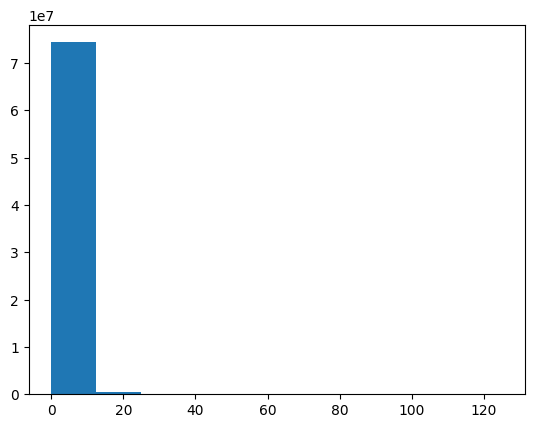

In [386]:
plt.hist(bn_spikes_big.flatten())

In [393]:
sizes = bn_spikes / 75
sizes_big = bn_spikes_big / (16 * 50)

(array([16119170.,  1120598.,   474275.,   257678.,   160182.,   106512.,
           76405.,    57306.,    44686.,   401688.]),
 array([0.        , 0.01333333, 0.02666667, 0.04      , 0.05333333,
        0.06666667, 0.08      , 0.09333333, 0.10666667, 0.12      ,
        0.13333333]),
 <BarContainer object of 10 artists>)

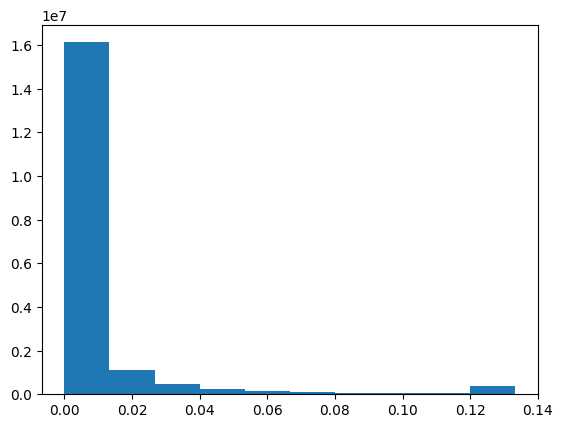

In [375]:
plt.hist(sizes.flatten())

(array([7.4403769e+07, 4.5500600e+05, 1.5089100e+05, 7.3767000e+04,
        4.3235000e+04, 2.6793000e+04, 1.9795000e+04, 1.4778000e+04,
        1.1798000e+04, 7.4168000e+04]),
 array([0.      , 0.015625, 0.03125 , 0.046875, 0.0625  , 0.078125,
        0.09375 , 0.109375, 0.125   , 0.140625, 0.15625 ]),
 <BarContainer object of 10 artists>)

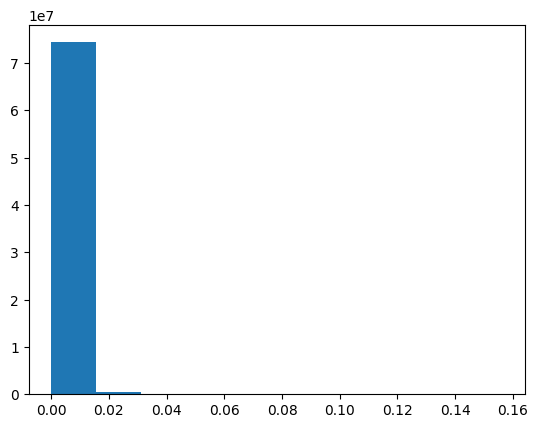

In [394]:

plt.hist(sizes_big.flatten())

In [377]:
raw_spikes[raw_spikes>250] = 250
raw_spikes[raw_spikes<0] = 0
raw_sizes = raw_spikes / 2000

(array([12908249.,  2771739.,  1179161.,   636434.,   399156.,   266447.,
          179480.,   126292.,    88953.,   232339.]),
 array([0.    , 0.0125, 0.025 , 0.0375, 0.05  , 0.0625, 0.075 , 0.0875,
        0.1   , 0.1125, 0.125 ]),
 <BarContainer object of 10 artists>)

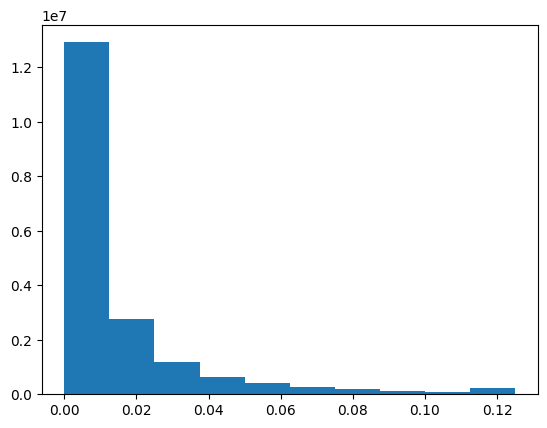

In [378]:
plt.hist(raw_sizes.flatten())

In [379]:
dark = True

urchin.camera.main.set_background_color("#000000" if dark else "#ffffff")
urchin.camera.main.set_rotation([22.5,22.5,225])
urchin.camera.main.set_mode("perspective")
urchin.camera.main.set_zoom(50)
urchin.camera.set_brain_rotation(0)

active_text[0].set_text("Quiescent period")
active_text[0].set_font_size(100)
active_text[0].set_color("#ffffff" if dark else "#000000")
active_text[0].set_position([-0.95, 0.95])

In [ ]:
total_s = 20


def set_view(frame: int):
    """Set the view for"""

    if frame < 300:
        active_text[0].set_text("Quiescent period")
    elif frame < 458:
        active_text[0].set_text("Trial start")
    elif frame < 699:
        active_text[0].set_text("Movement onset")
    else:
        active_text[0].set_text("Feedback")
    urchin.camera.set_brain_rotation(-15 + frame * 30 / 1000)

    # reorganize sizes into a list of triplet values
    sizes_list = []
    for i in np.arange(len(raw)):
        size = sizes_big[i, frame]
        sizes_list.append([size, size, size])
    
    urchin.meshes.set_scales(pmeshes, list(sizes_list))

In [ ]:
await urchin.camera.main.capture_video(file_name='mov.mp4', callback=set_view, duration=total_s, size=(480, 320), frame_rate=25)

(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera re

In [ ]:
await urchin.camera.main.capture_video(file_name='mov_baseline_normalized_dark.mp4', callback=set_view, duration=total_s, size=(2560, 1440), frame_rate=50)

(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera re

In [297]:
total_s = 10


def set_view_raw(frame: int):
    """Set the view for"""

    if frame < 75:
        active_text[0].set_text("Quiescent period")
    elif frame < 114:
        active_text[0].set_text("Trial start")
    elif frame < 174:
        active_text[0].set_text("Movement onset")
    else:
        active_text[0].set_text("Feedback")
    # urchin.camera.set_brain_rotation(0 + frame * 360 / 250)

    # reorganize sizes into a list of triplet values
    sizes_list = []
    for i in np.arange(len(raw)):
        size = raw_sizes[i, frame]
        sizes_list.append([size, size, size])
    
    urchin.meshes.set_scales(pmeshes, list(sizes_list))

In [298]:
await urchin.camera.main.capture_video(file_name='mov_raw.mp4', callback=set_view_raw, duration=total_s, size=(480,320), frame_rate=25)

(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera receive) Camera CameraMain received an image
(Camera receive) CameraMain complete
(Camera re